# Resumen del notebook
## Objetivo general
Seleccionar el subconjunto optimo de variables para predecir churn usando ABC.
### Flujo de trabajo
Se ejecuta preparacion de datos, ajuste del algoritmo, reporte y visualizacion.


In [17]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import random
import time
    # Import local para evitar dependencia si no se usa la función
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)


# Preparacion de datos
## Carga o generacion
Se crea el dataset (o se carga) con las columnas necesarias para el modelo.
### Preprocesamiento
Se codifican categorias, se separan X/y y se aplica escalado.


In [18]:
def cargar_y_preprocesar_datos():
    """
    Descarga el dataset real desde KaggleHub y aplica preprocesamiento.
    Dataset: shantanudhakadd/bank-customer-churn-prediction
    """
    print("=" * 70)
    print("  CARGA Y PREPROCESAMIENTO DEL DATASET")
    print("=" * 70)

    print("  → Descargando dataset real desde KaggleHub...")
    file_path = "Churn_Modelling.csv"
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "shantanudhakadd/bank-customer-churn-prediction",
        file_path,
    )

    df.columns = [col.strip() for col in df.columns]

    columnas_a_eliminar = ['RowNumber', 'CustomerId', 'Surname', 'customer_id']
    df.drop(columns=[c for c in columnas_a_eliminar if c in df.columns], inplace=True)

    renombrar = {
        'CreditScore': 'credit_score',
        'Geography'  : 'country',
        'Gender'     : 'gender',
        'Age'        : 'age',
        'Tenure'     : 'tenure',
        'Balance'    : 'balance',
        'NumOfProducts': 'products_number',
        'HasCrCard'  : 'credit_card',
        'IsActiveMember': 'active_member',
        'EstimatedSalary': 'estimated_salary',
        'Exited'     : 'churn',
    }
    df.rename(columns=renombrar, inplace=True)

    if 'churn' not in df.columns:
        raise ValueError("La columna objetivo 'churn' no se encuentra en el dataset.")

    df['balance'] = df['balance'].fillna(0)

    print("  → Aplicando preprocesamiento...")

    codificador = LabelEncoder()
    for columna in ['country', 'gender']:
        if columna in df.columns:
            df[columna] = codificador.fit_transform(df[columna])

    variable_objetivo = 'churn'
    caracteristicas   = [col for col in df.columns if col != variable_objetivo]

    X = df[caracteristicas].values
    y = df[variable_objetivo].values

    escalador  = StandardScaler()
    X_escalado = escalador.fit_transform(X)

    print(f"  → Dataset listo: {X_escalado.shape[0]} muestras, "
          f"{X_escalado.shape[1]} características")
    print(f"  → Distribución de clase objetivo: "
          f"No churn={np.sum(y==0)} | Churn={np.sum(y==1)}")
    print(f"  → Nombres de características: {caracteristicas}")
    print()

    return X_escalado, y, caracteristicas


# Algoritmo ABC
## Definicion de la clase
Se declara la clase con parametros, estado interno y utilidades.
### Fases y fitness
Se implementan fases de abejas y la funcion de aptitud con CV.


In [19]:
class ABC_SeleccionCaracteristicas:
    """
    Algoritmo de Colonia Artificial de Abejas (ABC) adaptado para
    el problema de Selección de Características (Feature Selection).

    Parámetros
    ----------
    num_abejas_empleadas : int
        Número de abejas empleadas (= número de fuentes de alimento).
    num_iteraciones      : int
        Número máximo de ciclos del algoritmo (criterio de parada).
    limite_abandono      : int
        Ciclos sin mejora antes de que una fuente sea abandonada.
    modelo_clasificacion : str
        'random_forest' o 'regresion_logistica'.
    metrica              : str
        'f1' o 'accuracy'. Métrica para evaluar la aptitud.
    penalizacion         : float
        Peso de la penalización por usar muchas características.
    num_folds_cv         : int
        Número de particiones para validación cruzada estratificada.
    """

    def __init__(
        self,
        num_abejas_empleadas : int   = 20,
        num_iteraciones      : int   = 50,
        limite_abandono      : int   = 10,
        modelo_clasificacion : str   = 'random_forest',
        metrica              : str   = 'f1',
        penalizacion         : float = 0.01,
        num_folds_cv         : int   = 3,
    ):
        self.num_abejas_empleadas = num_abejas_empleadas
        self.num_iteraciones      = num_iteraciones
        self.limite_abandono      = limite_abandono
        self.modelo_clasificacion = modelo_clasificacion
        self.metrica              = metrica
        self.penalizacion         = penalizacion
        self.num_folds_cv         = num_folds_cv

        self.fuentes_alimento     = None
        self.aptitudes            = None
        self.contadores_abandono  = None
        self.mejor_solucion       = None
        self.mejor_aptitud        = -np.inf
        self.historial_aptitud    = []
        self.num_caracteristicas  = None

    def _crear_solucion_binaria(self) -> np.ndarray:
        """
        Crea una solución binaria aleatoria.
        Asegura que al menos 1 característica esté seleccionada.
        """
        while True:
            solucion = np.random.randint(0, 2, self.num_caracteristicas)
            if solucion.sum() >= 1:
                return solucion

    def _calcular_aptitud(
        self, solucion: np.ndarray, X: np.ndarray, y: np.ndarray
    ) -> float:
        """
        Evalúa la calidad (aptitud) de un subconjunto de características.
        """
        indices_seleccionados = np.where(solucion == 1)[0]

        if len(indices_seleccionados) == 0:
            return 0.0

        X_subconjunto = X[:, indices_seleccionados]

        if self.modelo_clasificacion == 'random_forest':
            clasificador = RandomForestClassifier(
                n_estimators=50,
                max_depth=5,
                random_state=42,
                n_jobs=-1
            )
        else:
            clasificador = LogisticRegression(
                max_iter=200,
                random_state=42,
                solver='lbfgs',
                n_jobs=-1
            )

        cv_estratificada = StratifiedKFold(
            n_splits=self.num_folds_cv,
            shuffle=True,
            random_state=42
        )

        scoring = 'f1' if self.metrica == 'f1' else 'accuracy'

        puntuaciones = cross_val_score(
            clasificador,
            X_subconjunto,
            y,
            cv=cv_estratificada,
            scoring=scoring,
            n_jobs=-1
        )

        metrica_media = puntuaciones.mean()
        proporcion_usada = len(indices_seleccionados) / self.num_caracteristicas
        aptitud_final    = metrica_media - (self.penalizacion * proporcion_usada)

        return aptitud_final

    def _inicializar_enjambre(self, X: np.ndarray, y: np.ndarray):
        """
        Inicializa la población de fuentes de alimento y calcula
        la aptitud inicial de cada una.
        """
        self.num_caracteristicas = X.shape[1]

        print("  Inicializando enjambre...")
        print(f"  → {self.num_abejas_empleadas} abejas empleadas "
              f"(= {self.num_abejas_empleadas} fuentes de alimento)")

        self.fuentes_alimento = np.array([
            self._crear_solucion_binaria()
            for _ in range(self.num_abejas_empleadas)
        ])

        self.aptitudes = np.array([
            self._calcular_aptitud(self.fuentes_alimento[i], X, y)
            for i in range(self.num_abejas_empleadas)
        ])

        self.contadores_abandono = np.zeros(self.num_abejas_empleadas, dtype=int)

        indice_mejor        = np.argmax(self.aptitudes)
        self.mejor_solucion = self.fuentes_alimento[indice_mejor].copy()
        self.mejor_aptitud  = self.aptitudes[indice_mejor]
        self.historial_aptitud.append(self.mejor_aptitud)

        print(f"  → Aptitud inicial más alta: {self.mejor_aptitud:.4f}")
        print(f"  → Características en la mejor solución inicial: "
              f"{int(self.mejor_solucion.sum())}/{self.num_caracteristicas}")

    def _fase_abejas_empleadas(self, X: np.ndarray, y: np.ndarray):
        """
        Fase de abejas empleadas: cada abeja intenta mejorar su
        fuente de alimento mediante una modificación local (flip bit).
        """
        for i in range(self.num_abejas_empleadas):
            solucion_vecina = self.fuentes_alimento[i].copy()

            dimension_flip  = random.randint(0, self.num_caracteristicas - 1)
            solucion_vecina[dimension_flip] = 1 - solucion_vecina[dimension_flip]

            if solucion_vecina.sum() == 0:
                solucion_vecina[dimension_flip] = 1

            aptitud_vecina = self._calcular_aptitud(solucion_vecina, X, y)

            if aptitud_vecina > self.aptitudes[i]:
                self.fuentes_alimento[i] = solucion_vecina
                self.aptitudes[i]        = aptitud_vecina
                self.contadores_abandono[i] = 0
            else:
                self.contadores_abandono[i] += 1

    def _fase_abejas_observadoras(self, X: np.ndarray, y: np.ndarray):
        """
        Fase de abejas observadoras: seleccionan fuentes de alimento
        con probabilidad proporcional a su aptitud y las refinan.
        """
        aptitudes_ajustadas = self.aptitudes - self.aptitudes.min() + 1e-6
        probabilidades      = aptitudes_ajustadas / aptitudes_ajustadas.sum()

        for _ in range(self.num_abejas_empleadas):
            indice_fuente = np.random.choice(
                self.num_abejas_empleadas,
                p=probabilidades
            )

            solucion_vecina = self.fuentes_alimento[indice_fuente].copy()
            dimension_flip  = random.randint(0, self.num_caracteristicas - 1)
            solucion_vecina[dimension_flip] = 1 - solucion_vecina[dimension_flip]

            if solucion_vecina.sum() == 0:
                solucion_vecina[dimension_flip] = 1

            aptitud_vecina = self._calcular_aptitud(solucion_vecina, X, y)

            if aptitud_vecina > self.aptitudes[indice_fuente]:
                self.fuentes_alimento[indice_fuente] = solucion_vecina
                self.aptitudes[indice_fuente]        = aptitud_vecina
                self.contadores_abandono[indice_fuente] = 0
            else:
                self.contadores_abandono[indice_fuente] += 1

    def _fase_abejas_exploradoras(self, X: np.ndarray, y: np.ndarray):
        """
        Fase de abejas exploradoras: reemplaza fuentes agotadas por
        nuevas fuentes generadas aleatoriamente.
        """
        fuentes_agotadas = np.where(
            self.contadores_abandono >= self.limite_abandono
        )[0]

        for indice in fuentes_agotadas:
            nueva_fuente   = self._crear_solucion_binaria()
            nueva_aptitud  = self._calcular_aptitud(nueva_fuente, X, y)

            self.fuentes_alimento[indice] = nueva_fuente
            self.aptitudes[indice]        = nueva_aptitud
            self.contadores_abandono[indice] = 0

    def _actualizar_mejor_solucion(self):
        """
        Actualiza la mejor solución global encontrada hasta el momento.
        """
        indice_mejor   = np.argmax(self.aptitudes)
        mejor_aptitud  = self.aptitudes[indice_mejor]

        if mejor_aptitud > self.mejor_aptitud:
            self.mejor_aptitud  = mejor_aptitud
            self.mejor_solucion = self.fuentes_alimento[indice_mejor].copy()

    def ajustar(self, X: np.ndarray, y: np.ndarray):
        """
        Ejecuta el ciclo completo del algoritmo ABC.
        """
        print("\n" + "=" * 70)
        print("  INICIANDO ALGORITMO ABC - SELECCIÓN DE CARACTERÍSTICAS")
        print("=" * 70)

        tiempo_inicio = time.time()

        self._inicializar_enjambre(X, y)

        ciclos_sin_mejora_global = 0
        limite_estancamiento     = max(10, self.num_iteraciones // 5)

        print(f"\n  Ejecutando {self.num_iteraciones} iteraciones...\n")

        for iteracion in range(1, self.num_iteraciones + 1):
            aptitud_antes = self.mejor_aptitud

            self._fase_abejas_empleadas(X, y)
            self._fase_abejas_observadoras(X, y)
            self._fase_abejas_exploradoras(X, y)

            self._actualizar_mejor_solucion()
            self.historial_aptitud.append(self.mejor_aptitud)

            if self.mejor_aptitud > aptitud_antes + 1e-6:
                ciclos_sin_mejora_global = 0
            else:
                ciclos_sin_mejora_global += 1

            if iteracion % 10 == 0 or iteracion == 1:
                num_caract_selec = int(self.mejor_solucion.sum())
                print(f"  Iter {iteracion:3d}/{self.num_iteraciones} | "
                      f"Mejor aptitud: {self.mejor_aptitud:.4f} | "
                      f"Características: {num_caract_selec}/{self.num_caracteristicas} | "
                      f"Sin mejora: {ciclos_sin_mejora_global}/{limite_estancamiento}")

            if ciclos_sin_mejora_global >= limite_estancamiento:
                print(f"\n Detención temprana en iteración {iteracion}: "
                      f"sin mejora durante {ciclos_sin_mejora_global} ciclos.")
                break

        tiempo_total = time.time() - tiempo_inicio
        print(f"\n ABC finalizado en {tiempo_total:.1f} segundos.")

        return self


# Visualizacion
## Evolucion y seleccion
Se grafican la aptitud por iteracion y el estado de cada variable.
### Comparativas
Se compara el F1 y se muestra la importancia de variables seleccionadas.


In [20]:
def visualizar_resultados(
    algoritmo   : ABC_SeleccionCaracteristicas,
    X           : np.ndarray,
    y           : np.ndarray,
    nombres_caract : list
):
    """
    Genera un panel de visualizaciones con los resultados del ABC:
      1. Evolución de la aptitud por iteración.
      2. Mapa de características seleccionadas vs excluidas.
      3. Importancia de características (si se usa Random Forest).
      4. Comparativa: todas las características vs subconjunto óptimo.
    """
    mejor_solucion       = algoritmo.mejor_solucion
    indices_seleccionados= np.where(mejor_solucion == 1)[0]
    nombres_seleccionados= [nombres_caract[i] for i in indices_seleccionados]
    historial            = algoritmo.historial_aptitud

    COLOR_FONDO   = '#0D1117'
    COLOR_PANEL   = '#161B22'
    COLOR_ACENTO1 = '#F7B731'
    COLOR_ACENTO2 = '#20BF6B'
    COLOR_ACENTO3 = '#EB3B5A'
    COLOR_TEXTO   = '#E6EDF3'

    fig = plt.figure(figsize=(18, 12), facecolor=COLOR_FONDO)
    fig.suptitle(
        '🐝  Algoritmo ABC — Selección de Características | Bank Churn',
        fontsize=16, fontweight='bold', color=COLOR_ACENTO1, y=0.98
    )

    ax1 = fig.add_subplot(2, 2, 1)
    ax2 = fig.add_subplot(2, 2, 2)
    ax3 = fig.add_subplot(2, 2, 3)
    ax4 = fig.add_subplot(2, 2, 4)

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_facecolor(COLOR_PANEL)
        for spine in ax.spines.values():
            spine.set_color('#30363D')

    ax1.plot(historial, color=COLOR_ACENTO1, linewidth=2, zorder=3)
    ax1.fill_between(
        range(len(historial)), historial,
        alpha=0.2, color=COLOR_ACENTO1
    )
    ax1.set_title('Evolución de la Aptitud (ABC)', color=COLOR_TEXTO,
                  fontweight='bold', pad=12)
    ax1.set_xlabel('Iteración', color=COLOR_TEXTO)
    ax1.set_ylabel(f'{algoritmo.metrica.upper()} ajustado', color=COLOR_TEXTO)
    ax1.tick_params(colors=COLOR_TEXTO)
    ax1.axhline(max(historial), color=COLOR_ACENTO2, linestyle='--',
                alpha=0.6, label=f'Máx: {max(historial):.4f}')
    ax1.legend(facecolor=COLOR_PANEL, labelcolor=COLOR_TEXTO, fontsize=9)
    ax1.grid(True, alpha=0.15, color='#30363D')

    estados = mejor_solucion.astype(int)
    colores = [COLOR_ACENTO2 if e == 1 else COLOR_ACENTO3 for e in estados]
    barras  = ax2.barh(nombres_caract, estados, color=colores, edgecolor='none')

    ax2.set_title('Características Seleccionadas por el ABC',
                  color=COLOR_TEXTO, fontweight='bold', pad=12)
    ax2.set_xlabel('Estado (1 = Incluida, 0 = Excluida)', color=COLOR_TEXTO)
    ax2.tick_params(colors=COLOR_TEXTO)
    ax2.set_xlim(0, 1.3)

    for i, (barra, estado) in enumerate(zip(barras, estados)):
        etiqueta = '✓ Incluida' if estado == 1 else '✗ Excluida'
        ax2.text(1.05, i, etiqueta,
                 va='center', ha='left',
                 fontsize=8, color=COLOR_ACENTO2 if estado == 1 else COLOR_ACENTO3)

    parche_verde = mpatches.Patch(color=COLOR_ACENTO2, label='Seleccionada')
    parche_rojo  = mpatches.Patch(color=COLOR_ACENTO3, label='Excluida')
    ax2.legend(handles=[parche_verde, parche_rojo],
               facecolor=COLOR_PANEL, labelcolor=COLOR_TEXTO,
               loc='lower right', fontsize=8)

    clf_todas = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    clf_optim = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    f1_todas = cross_val_score(clf_todas, X, y, cv=cv, scoring='f1', n_jobs=-1).mean()
    f1_optim = cross_val_score(
        clf_optim, X[:, indices_seleccionados], y, cv=cv, scoring='f1', n_jobs=-1
    ).mean()

    etiquetas   = ['Todas\n(11 características)', f'Subconjunto ABC\n({len(indices_seleccionados)} características)']
    valores_f1  = [f1_todas, f1_optim]
    barra_colores = [COLOR_ACENTO3, COLOR_ACENTO2]

    barras3 = ax3.bar(etiquetas, valores_f1, color=barra_colores,
                      width=0.4, edgecolor='none')
    ax3.set_ylim(0, min(1.0, max(valores_f1) * 1.25))
    ax3.set_title('Comparativa F1-Score: Todas vs Óptimo',
                  color=COLOR_TEXTO, fontweight='bold', pad=12)
    ax3.set_ylabel('F1-Score (Validación Cruzada)', color=COLOR_TEXTO)
    ax3.tick_params(colors=COLOR_TEXTO)
    ax3.grid(True, alpha=0.15, axis='y', color='#30363D')

    for barra, val in zip(barras3, valores_f1):
        ax3.text(barra.get_x() + barra.get_width() / 2,
                 barra.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom',
                 color=COLOR_TEXTO, fontweight='bold', fontsize=11)

    clf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf_final.fit(X[:, indices_seleccionados], y)
    importancias = clf_final.feature_importances_

    orden = np.argsort(importancias)[::-1]
    nombres_ord   = [nombres_seleccionados[i] for i in orden]
    importancias_ord = importancias[orden]

    gradient_colors = plt.cm.YlOrBr(
        np.linspace(0.3, 0.9, len(nombres_ord))[::-1]
    )
    ax4.barh(nombres_ord[::-1], importancias_ord[::-1],
             color=gradient_colors[::-1], edgecolor='none')
    ax4.set_title('Importancia de Características Seleccionadas\n(Random Forest)',
                  color=COLOR_TEXTO, fontweight='bold', pad=12)
    ax4.set_xlabel('Importancia Media', color=COLOR_TEXTO)
    ax4.tick_params(colors=COLOR_TEXTO)
    ax4.grid(True, alpha=0.15, axis='x', color='#30363D')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('abc_resultados.png', dpi=150, bbox_inches='tight',
                facecolor=COLOR_FONDO)
    plt.show()
    print("\n  Figura guardada como: abc_resultados.png")


# Reporte final
## Resultado del subconjunto
Se listan variables seleccionadas y excluidas por el algoritmo.
### Metricas
Se calcula F1 y accuracy con validacion cruzada sobre el subconjunto.


In [21]:
def imprimir_reporte_final(
    algoritmo      : ABC_SeleccionCaracteristicas,
    X              : np.ndarray,
    y              : np.ndarray,
    nombres_caract : list
):
    """
    Imprime un reporte detallado con la solución óptima encontrada
    y el rendimiento final del clasificador sobre esa selección.
    """
    mejor_solucion        = algoritmo.mejor_solucion
    indices_seleccionados = np.where(mejor_solucion == 1)[0]
    nombres_seleccionados = [nombres_caract[i] for i in indices_seleccionados]
    nombres_excluidos     = [nombres_caract[i]
                             for i in range(len(nombres_caract))
                             if i not in indices_seleccionados]

    print("\n" + "=" * 70)
    print("  REPORTE FINAL — ALGORITMO ABC")
    print("=" * 70)
    print(f"\n  Mejor aptitud alcanzada : {algoritmo.mejor_aptitud:.4f}")
    print(f"\n  Características SELECCIONADAS "
          f"({len(nombres_seleccionados)}/{len(nombres_caract)}):")
    for n in nombres_seleccionados:
        print(f"       ✓  {n}")

    print(f"\n  Características EXCLUIDAS "
          f"({len(nombres_excluidos)}/{len(nombres_caract)}):")
    for n in nombres_excluidos:
        print(f"       ✗  {n}")

    X_optimo = X[:, indices_seleccionados]
    clf      = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_final  = cross_val_score(clf, X_optimo, y, cv=cv, scoring='f1',       n_jobs=-1).mean()
    acc_final = cross_val_score(clf, X_optimo, y, cv=cv, scoring='accuracy',  n_jobs=-1).mean()

    print("\n  Rendimiento final con el subconjunto óptimo "
          "(Random Forest, CV-5):")
    print(f"       F1-Score : {f1_final:.4f}")
    print(f"       Accuracy : {acc_final:.4f}")
    print(f"\n  Reducción de dimensionalidad: "
          f"{len(nombres_caract)} → {len(nombres_seleccionados)} características "
          f"({100*(1-len(nombres_seleccionados)/len(nombres_caract)):.1f}% reducción)")
    print("=" * 70 + "\n")


# Ejecucion
## Pipeline completo
Se corre la carga de datos, el ajuste del ABC y el reporte.
### Salidas
Se muestran metricas finales y graficas generadas.


  CARGA Y PREPROCESAMIENTO DEL DATASET
  → Descargando dataset real desde KaggleHub...
Download already complete (684858 bytes).
  → Aplicando preprocesamiento...
  → Dataset listo: 10000 muestras, 10 características
  → Distribución de clase objetivo: No churn=7963 | Churn=2037
  → Nombres de características: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


  INICIANDO ALGORITMO ABC - SELECCIÓN DE CARACTERÍSTICAS
  Inicializando enjambre...
  → 20 abejas empleadas (= 20 fuentes de alimento)
  → Aptitud inicial más alta: 0.5140
  → Características en la mejor solución inicial: 5/10

  Ejecutando 50 iteraciones...

  Iter   1/50 | Mejor aptitud: 0.5289 | Características: 4/10 | Sin mejora: 0/10
  Iter  10/50 | Mejor aptitud: 0.5296 | Características: 4/10 | Sin mejora: 1/10

 Detención temprana en iteración 19: sin mejora durante 10 ciclos.

 ABC finalizado en 357.3 segundos.

  REPORTE FINAL — ALG

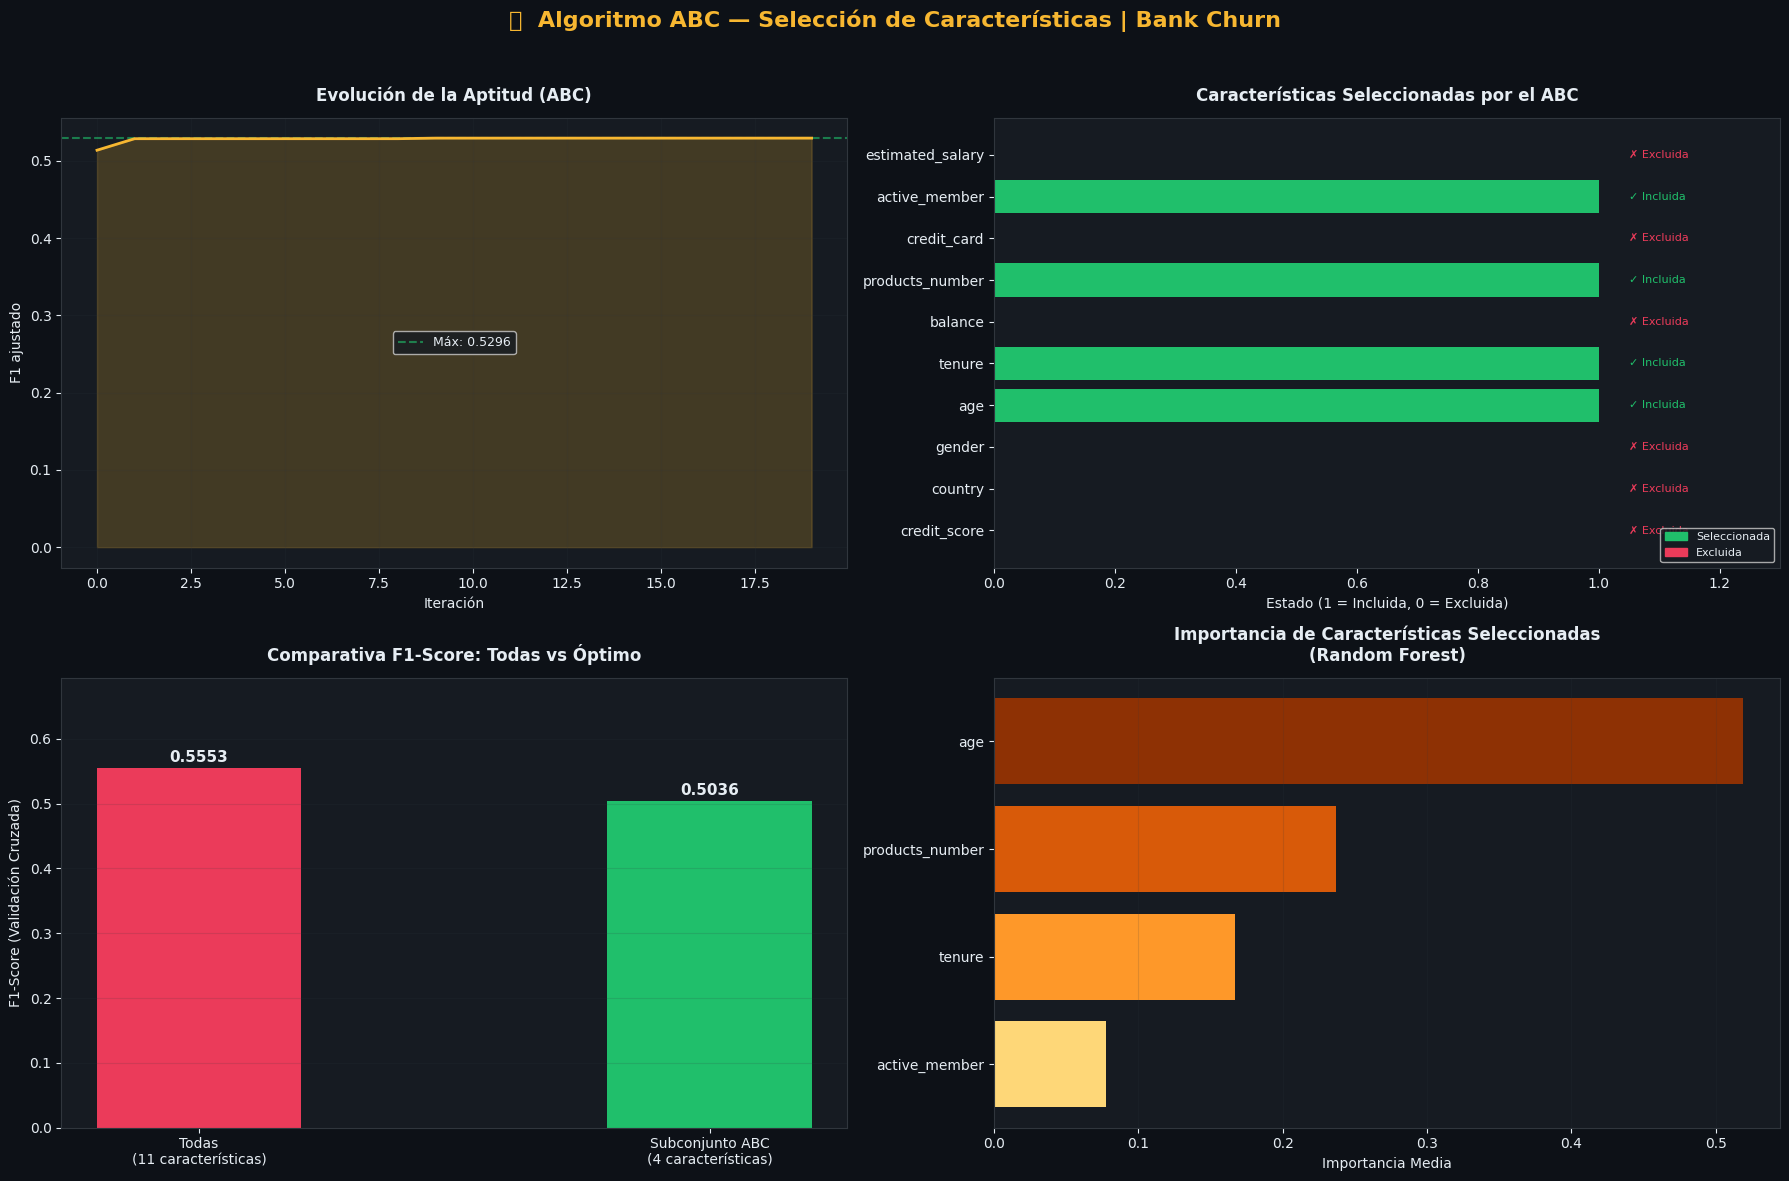


  Figura guardada como: abc_resultados.png


In [22]:
if __name__ == "__main__":

    X, y, nombres_caracteristicas = cargar_y_preprocesar_datos()

    abc = ABC_SeleccionCaracteristicas(
        num_abejas_empleadas = 20,
        num_iteraciones      = 50,
        limite_abandono      = 10,
        modelo_clasificacion = 'random_forest',
        metrica              = 'f1',
        penalizacion         = 0.01,
        num_folds_cv         = 3,
    )

    abc.ajustar(X, y)

    imprimir_reporte_final(abc, X, y, nombres_caracteristicas)

    visualizar_resultados(abc, X, y, nombres_caracteristicas)
